In [ ]:
import os
import cv2
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from sklearn.utils import shuffle
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, auc
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras import layers, models
from tensorflow.keras.layers import ( GlobalAveragePooling2D, Dense, Dropout,  BatchNormalization, GaussianNoise, Input, MultiHeadAttention, Reshape)
from tensorflow.keras.applications.xception import Xception, preprocess_input
from sklearn.model_selection import train_test_split
import random
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical

from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout


import warnings
warnings.filterwarnings("ignore")

2025-09-02 16:11:59.360760: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1756829519.575042      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1756829519.636501      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [ ]:
SEED = 23
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

Height = 244
Width = 244

Channal = 3
BATCH_SIZE = 16
epochs = 20

Number_Classes = 8

Dense_Layr_Actication = 'softmax'
Objective_Function = 'categorical_crossentropy'

In [ ]:
Data_Path = '/kaggle/input/facial-emotion-recognition/images'
img_path = []

In [ ]:
for folder in os.listdir(Data_Path):
    folder_path = os.path.join(Data_Path , folder)
    for img in os.listdir(folder_path):
        if img.lower().endswith((".jpg",".jpeg",".png",".bmp",".tif",".tiff")):
                img_path.append(os.path.join(folder_path , img))
        else:
         print("NOT FOUND!!")



data = pd.DataFrame({"Image_Path": img_path})



In [ ]:
data

,Image_Path
0,/kaggle/input/facial-emotion-recognition/image...
1,/kaggle/input/facial-emotion-recognition/image...
2,/kaggle/input/facial-emotion-recognition/image...
3,/kaggle/input/facial-emotion-recognition/image...
4,/kaggle/input/facial-emotion-recognition/image...
...,...
147,/kaggle/input/facial-emotion-recognition/image...
148,/kaggle/input/facial-emotion-recognition/image...
149,/kaggle/input/facial-emotion-recognition/image...
150,/kaggle/input/facial-emotion-recognition/image...


In [ ]:
data['Image_Path'][5].split('/')

['',
 'kaggle',
 'input',
 'facial-emotion-recognition',
 'images',
 '7',
 'Happy.jpg']

In [ ]:
lb = data['Image_Path'][0].split('/')
lb[-1:][0].split('.')[0]

'Disgust'

In [ ]:
data['Label'] = data['Image_Path'].apply(lambda x: x.split('/')[-1].split('.')[0])

In [ ]:
data

,Image_Path,Label
0,/kaggle/input/facial-emotion-recognition/image...,Disgust
1,/kaggle/input/facial-emotion-recognition/image...,Anger
2,/kaggle/input/facial-emotion-recognition/image...,Sad
3,/kaggle/input/facial-emotion-recognition/image...,Surprised
4,/kaggle/input/facial-emotion-recognition/image...,Neutral
...,...,...
147,/kaggle/input/facial-emotion-recognition/image...,Surprised
148,/kaggle/input/facial-emotion-recognition/image...,Neutral
149,/kaggle/input/facial-emotion-recognition/image...,Happy
150,/kaggle/input/facial-emotion-recognition/image...,Fear


In [ ]:
data['Label'].value_counts()

Label
Disgust      19
Anger        19
Sad          19
Surprised    19
Neutral      19
Happy        19
Fear         19
Contempt     19
Name: count, dtype: int64

In [ ]:
data.shape

(152, 2)

In [ ]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 152 entries, 0 to 151
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Image_Path  152 non-null    object
 1   Label       152 non-null    object
dtypes: object(2)
memory usage: 2.5+ KB


In [ ]:
data.duplicated().sum()

0

In [ ]:
data.isna().sum()


Image_Path    0
Label         0
dtype: int64

In [ ]:
classes = sorted(data["Label"].unique())
Number_Classes = len(classes)
print("Classes:", classes, " | num_classes:", Number_Classes)

Classes: ['Anger', 'Contempt', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprised']  | num_classes: 8


In [ ]:
152 / 8

19.0

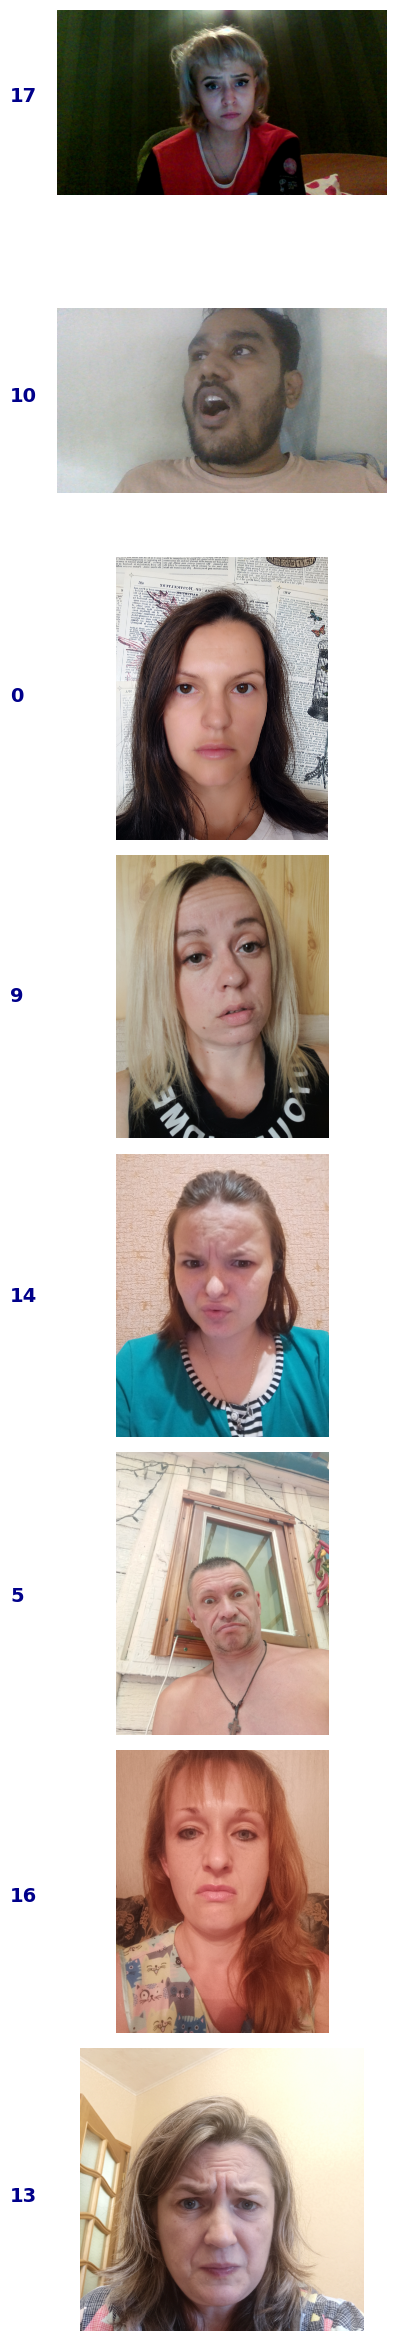

In [ ]:

CLASSES_TO_SHOW =  Number_Classes
IMAGES_PER_CLASS = 1


def show_images_from_dataset(Data_Path, classes_to_show, images_per_class):
    class_names = sorted(os.listdir(Data_Path))

    selected_classes = random.sample(class_names, classes_to_show)

    fig, axes = plt.subplots(classes_to_show, images_per_class, figsize=(4*images_per_class, 3*classes_to_show))

    if classes_to_show == 1:
        axes = [axes]

    for i, cls in enumerate(selected_classes):
        class_dir = os.path.join(Data_Path, cls)
        images = os.listdir(class_dir)
        selected_images = random.sample(images, min(images_per_class, len(images)))

        for j, img_name in enumerate(selected_images):
            img_path = os.path.join(class_dir, img_name)
            img = plt.imread(img_path)

            if images_per_class == 1:
                ax = axes[i]
            else:
                ax = axes[i, j]

            ax.imshow(img)
            ax.axis("off")


        fig.text(
            0.02,
            1 - (i+0.5)/classes_to_show,
            cls,
            ha="left", va="center",
            fontsize=14, fontweight="bold", color="darkblue"
        )

    plt.tight_layout(rect=[0.1, 0, 1, 1])
    plt.show()



show_images_from_dataset(Data_Path, CLASSES_TO_SHOW, IMAGES_PER_CLASS)

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data["Label"] = le.fit_transform(data["Label"])

print(le.classes_)


['Anger' 'Contempt' 'Disgust' 'Fear' 'Happy' 'Neutral' 'Sad' 'Surprised']


In [ ]:
X = []
y = []
for feature, label in data.values:
    image = cv2.imread(feature)
    image = cv2.resize(image, (224, 224), interpolation = cv2.INTER_LINEAR)
    X.append(image)
    y.append(label)
X = np.array(X)
y = np.array(y)

In [ ]:
datagen = ImageDataGenerator(
    rotation_range=25,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [ ]:
augmented_X = []
augmented_y = []
for i in range(len(X)):
    img = X[i].reshape((1, *X[i].shape))
    label = y[i]
    for _ in range(50):
        augmented = next(datagen.flow(img, batch_size=1))
        augmented_X.append(augmented[0])
        augmented_y.append(label)
augmented_X = np.array(augmented_X)
augmented_y = np.array(augmented_y)

In [ ]:
X = np.concatenate([X, augmented_X], axis=0)
y = np.concatenate([y, augmented_y], axis=0)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)


In [ ]:
y_train = to_categorical(y_train, num_classes = 8)
y_test = to_categorical(y_test, num_classes = 8)

In [ ]:
early_stopping = EarlyStopping(monitor='val_accuracy', patience=10, mode='max', verbose=1, restore_best_weights=True)
lr_reduction = ReduceLROnPlateau(monitor='val_accuracy', patience=3, mode='max', verbose=1, factor=0.5, min_lr=0.0001)

In [ ]:
model = Sequential([
    Conv2D(32, (3,3), activation="relu", input_shape=(299,299, Channal)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(256, (3,3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(512, (3,3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D(2,2),

    GlobalAveragePooling2D(),
    Dense(256, activation="relu", kernel_regularizer=l2(1e-4)),
    Dropout(0.3),
    Dense(Number_Classes, activation="softmax")
])

I0000 00:00:1756829629.175702      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1756829629.176342      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [ ]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 297, 297, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 297, 297, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 148, 148, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 146, 146, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 146, 146, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 73, 73, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 71, 71, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 71, 71, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 35, 35, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 33, 33, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 33, 33, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 14, 14, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,705,928 (6.51 MB)

 Trainable params: 1,703,944 (6.50 MB)

 Non-trainable params: 1,984 (7.75 KB)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss=Objective_Function,
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    batch_size=BATCH_SIZE,
    validation_data=(X_test, y_test),
    epochs=epochs,
    callbacks=[early_stopping, lr_reduction]
)

Epoch 1/20


I0000 00:00:1756829645.211118      66 service.cc:148] XLA service 0x7c56e808c190 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1756829645.212038      66 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1756829645.212059      66 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1756829645.833592      66 cuda_dnn.cc:529] Loaded cuDNN version 90300


  3/388 ━━━━━━━━━━━━━━━━━━━━ 17s 46ms/step - accuracy: 0.1215 - loss: 2.9753   

I0000 00:00:1756829651.724471      66 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


388/388 ━━━━━━━━━━━━━━━━━━━━ 34s 57ms/step - accuracy: 0.1505 - loss: 2.3303 - val_accuracy: 0.2192 - val_loss: 2.0137 - learning_rate: 1.0000e-04
Epoch 2/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - accuracy: 0.2524 - loss: 1.9839 - val_accuracy: 0.2850 - val_loss: 1.9019 - learning_rate: 1.0000e-04
Epoch 3/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - accuracy: 0.3206 - loss: 1.8258 - val_accuracy: 0.3340 - val_loss: 1.7948 - learning_rate: 1.0000e-04
Epoch 4/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - accuracy: 0.4129 - loss: 1.6370 - val_accuracy: 0.3933 - val_loss: 1.6685 - learning_rate: 1.0000e-04
Epoch 5/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 15s 39ms/step - accuracy: 0.5326 - loss: 1.3715 - val_accuracy: 0.5068 - val_loss: 1.4410 - learning_rate: 1.0000e-04
Epoch 6/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 16s 40ms/step - accuracy: 0.6771 - loss: 1.0333 - val_accuracy: 0.6299 - val_loss: 1.1422 - learning_rate: 1.0000e-04
Epoch 7/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 15s 39ms/step - accurac